In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
# inplement Elastic Net next


In [ ]:
##
## Parameters
##

# time step
dt=0.0025
# units of time to warm up NVAR. need to have warmup_pts >= 1
warmup = 2.
# units of time to train for
traintime = 0.01
# units of time to test for
testtime=1.
# total time to run for
maxtime = warmup+traintime+testtime
# how much of testtime to plot
# plottime=2.
# Lyapunov time of the Lorenz system
lyaptime=1. # lyap time not know for this system, plug 1 in for comparison

# discrete-time versions of the times defined above
warmup_pts=round(warmup/dt)
traintime_pts=round(traintime/dt)
warmtrain_pts=warmup_pts+traintime_pts
testtime_pts=round(testtime/dt)
maxtime_pts=round(maxtime/dt)
# plottime_pts=round(plottime/dt)
lyaptime_pts=round(lyaptime/dt)

# input dimension
d = 3
# number of time delay taps
k = 2
# size of linear part of feature vector
dlin = k*d
# size of nonlinear part of feature vector
dnonlin = int(dlin*(dlin+1)/2)
# total size of feature vector: constant + linear + nonlinear
dtot = 1 + dlin + dnonlin

# param for ridge regression
ridge_param = 1.5e-6


# t values for whole evaluation time
# (need maxtime_pts + 1 to ensure a step of dt)
t_eval=np.linspace(0,maxtime,maxtime_pts+1)

##
## define system
##

def lorenz_63(X, t):
    # define constants
    a = 10
    b = 8/3
    r = 28

    # num state variables
    N = len(X)
    # initialize solution output for N state variables
    output_values = np.zeros(N)

    # assign state variable names
    x = X[0]
    y = X[1]
    z = X[2]
    # values
    output_values[0] = a * (y-x)
    output_values[1] = r*x - y - x*z
    output_values[2] = x*y - b*z

    return output_values

def lorenz_96(X,t,dim=4):
    # num state variables
    N = len(X)
    if N != dim:
        print('Lorenz 96: error in dim and lenght of X input')

    # initialize solution output for N state variables
    output_values = np.zeros(N)

    # define constants
    F = 10

    # update
    output_values = (np.roll(X,-1)-np.roll(X,2))*np.roll(X,1)- X + F

    return output_values

def lorenz_9dim(X, t):
# define constants
    a = 1/2 #10
    sigma = 0.5 # Prandtl number
    r = 28 # 28

    b1 = 4* (1+a**2)/(1+2*a**2)
    b2 = (1+2*a**2)/(2*(1+a**2))
    b3 = 2* (1-a**2)/(1+a**2)
    b4 = a**2 / (a+a**2)
    b5 = 8*a**2 /(1+2*a**2)
    b6 = 4/(1+2*a**2)

    # num state variables
    N = len(X)
    # initialize solution output for N state variables
    output_values = np.zeros(N)

    # assign state variable names
    c1 = X[0]
    c2 = X[1]
    c3 = X[2]
    c4 = X[3]
    c5 = X[4]
    c6 = X[5]
    c7 = X[6]
    c8 = X[7]
    c9 = X[8]
    # values
    output_values[0] = - sigma *b1*c1 - c2*c4 + b4*c4**2 + b3*c3*c5 - sigma*b2*c7
    output_values[1] = - sigma *c2 + c1*c4 -c2*c5+c4*c5-sigma*c9/2
    output_values[2] = - sigma * b1*c3 + c2*c4 - b4*c2**2 - b3*c1*c5 + sigma*b2*c8
    output_values[3] = -sigma * c4 - c2*c3-c2*c5+c4*c5+sigma*c9/2
    output_values[4] = -sigma*b5*c5 + c2**2/2 - c4*c9
    output_values[5] = -b6*c6+c2*c9-c4*c9
    output_values[6] = -b1*c7-r*c1+2*c5*c8 -c4*c9
    output_values[7] = -b1*c8 +r*c3 - 2*c5*c7 + c2*c9
    output_values[8] = -c9 -r*c2 + r*c4 - 2*c2*c6 + 2*c4*c6 +c4*c7-c2*c8 
    return output_values

# integrated out to t=50 to find points on the attractor, then use these as the initial conditions

# generates solution to system
def runge_kutta_4(f, X0, t, h):
    k1 = f( X0 , t )
    k2 = f( X0 + (h/2)*k1 , t + h/2 )
    k3 = f( X0 + (h/2)*k2 , t + h/2 )
    k4 = f( X0 + h*k3 , t + h)

    x1 = X0 + h/6 * (k1 + 2*k2 + 2*k3 + k4)
    return x1

def solver(f, X0 , h, n, t0):
    # f - function
    # X0 - initial condition
    # h - time step
    # n - number of time steps
    # t0 - initial time
    time_steps = np.linspace(t0, t0+h*n, n+1) # list of times
    trajectory_history = np.zeros([len(X0),len(time_steps)]) # initialize storage for trajectory path

    for i in range(len(time_steps)):
        t = time_steps[i]
        trajectory_history[:,i] = X0
        X0 = runge_kutta_4(f, X0, t, h)
    
    return trajectory_history, time_steps

# lorenz 63
X0 = np.array([17.67715816276679, 12.931379185960404, 43.91404334248268 ]) 
trajectory_history, time_history = solver(lorenz_63, X0, dt, maxtime_pts, 0)

# lorenz 96
# X0 = np.array([ 4.93059044, -2.9208414,   3.8355933,   8.98481607]) # 4 dim
# trajectory_history, time_history = solver(lorenz_96, X0, dt, maxtime_pts, 0)

# 9 dim lorenz
# X0 = np.array([  0.96803247,  -4.49827049,  -1.56463134,  -2.59560938,  -0.95404047,
#   -5.51041908,   0.35826517, -14.78422783,  -4.50578669])
# trajectory_history, time_history = solver(lorenz_9dim, X0, dt, maxtime_pts, 0)



# total variance of Lorenz solution
total_var=np.var(trajectory_history[0:d,:])

##
## NVAR
##

# create an array to hold the linear part of the feature vector
x = np.zeros((dlin,maxtime_pts))

# fill in the linear part of the feature vector for all times
for delay in range(k):
    for j in range(delay,maxtime_pts):
        x[d*delay:d*(delay+1),j]=trajectory_history[:,j-delay]

# create an array to hold the full feature vector for training time
# (use ones so the constant term is already 1)
out_train = np.ones((dtot,traintime_pts))

# copy over the linear part (shift over by one to account for constant)
out_train[1:dlin+1,:]=x[:,warmup_pts-1:warmtrain_pts-1]

# fill in the non-linear part
cnt=0
for row in range(dlin):
    for column in range(row,dlin):
        # shift by one for constant
        out_train[dlin+1+cnt]=x[row,warmup_pts-1:warmtrain_pts-1]*x[column,warmup_pts-1:warmtrain_pts-1]
        cnt += 1


#
# ridge regression: train W_out to map out_train to Lorenz[t] - Lorenz[t - 1]
#

## implicit W_out for ridge regression
W_out_ridge = (x[0:d,warmup_pts:warmtrain_pts]-x[0:d,warmup_pts-1:warmtrain_pts-1]) @ out_train[:,:].T @ np.linalg.pinv(out_train[:,:] @ out_train[:,:].T + ridge_param*np.identity(dtot))

# print(x[0:d,warmup_pts:warmtrain_pts]-x[0:d,warmup_pts-1:warmtrain_pts-1])
# print('+++++++++++++++++++++++++++++++++++++++++')
# print(out_train[:,:])
# print('+++++++++++++++++++++++++++++++++++++++++')
# print(W_out_ridge)

[[ 0.10585651  0.10599287  0.10603118  0.10597386]
 [ 0.11330335  0.10947043  0.10563441  0.10180233]
 [-0.10395252 -0.10706533 -0.11001433 -0.11280249]]
+++++++++++++++++++++++++++++++++++++++++
[[ 1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00]
 [-9.19531196e+00 -9.08945545e+00 -8.98346258e+00 -8.87743141e+00]
 [-4.96510965e+00 -4.85180630e+00 -4.74233587e+00 -4.63670146e+00]
 [ 3.24720251e+01  3.23680725e+01  3.22610072e+01  3.21509929e+01]
 [-9.30093174e+00 -9.19531196e+00 -9.08945545e+00 -8.98346258e+00]
 [-5.08223538e+00 -4.96510965e+00 -4.85180630e+00 -4.74233587e+00]
 [ 3.25726983e+01  3.24720251e+01  3.23680725e+01  3.22610072e+01]
 [ 8.45537621e+01  8.26182005e+01  8.07026000e+01  7.88087884e+01]
 [ 4.56557322e+01  4.41002772e+01  4.26025968e+01  4.11619992e+01]
 [-2.98590400e+02 -2.94208153e+02 -2.89815551e+02 -2.85418234e+02]
 [ 8.55249689e+01  8.35803785e+01  8.16547830e+01  7.97500729e+01]
 [ 4.67327398e+01  4.51301430e+01  4.35860203e+01  4.20997614e+01]


In [3]:
# print(np.arange(5e-5,7e-5+1e-10,1.e-6))

In [ ]:
# lasso_params = np.linspace(1e-10,1e-4,3)
# lasso_params = np.arange(5e-5,7e-5+1e-10,1.e-6) # np.arange(4e-6,5e-6+1e-10,0.25e-6)
lasso_params = np.array([4.5e-6])

X_data = out_train[:,:].T
y_data = (x[0:d,warmup_pts:warmtrain_pts]-x[0:d,warmup_pts-1:warmtrain_pts-1]).T

print('testing',len(lasso_params),'lasso paramater values:')
print(lasso_params)
coefs = []

lasso_tol = 0.0000001  # 1000000, 0.00001
for lambda_1 in lasso_params:
  print(f'testing paramater value {lambda_1}')
  lasso = Lasso(alpha=lambda_1,max_iter=50000000, tol=lasso_tol) 
  lasso.fit(X_data, y_data)
  coefs.append(lasso.coef_)
  num_iterations = lasso.n_iter_
  print('number of iterations per paramater:')
  print(num_iterations)
coefs = np.array(coefs)


print('Done')




testing 1 lasso paramater values:
[4.5e-06]
testing paramater value 4.5e-06


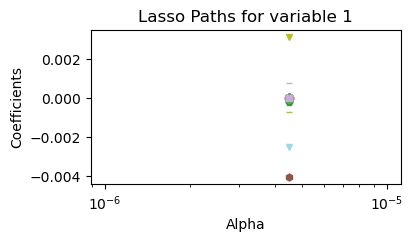

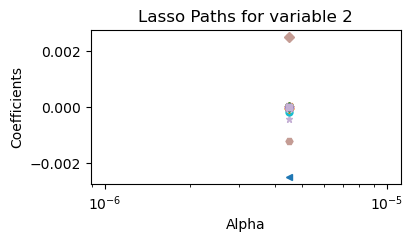

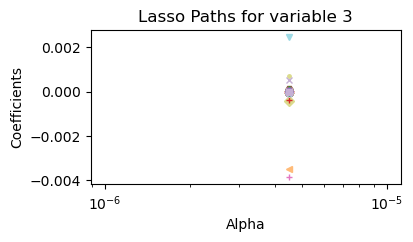

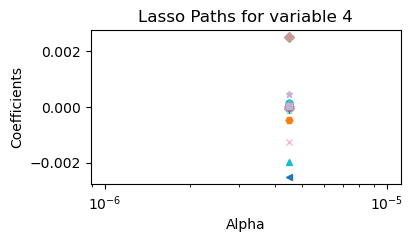

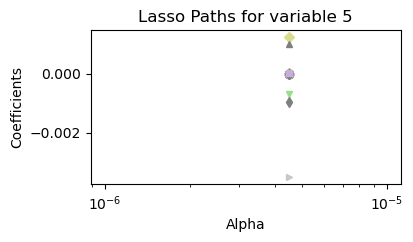

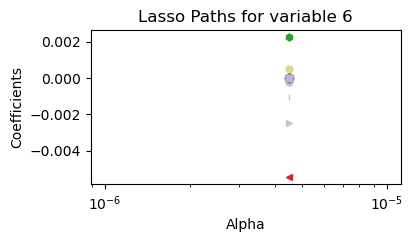

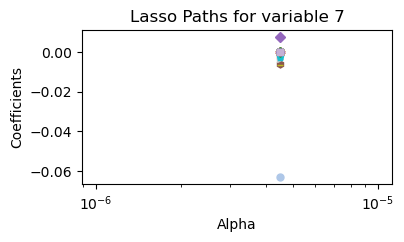

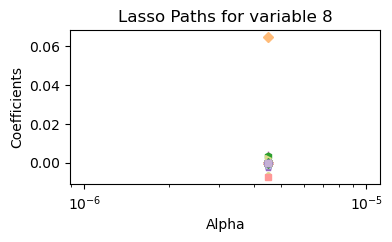

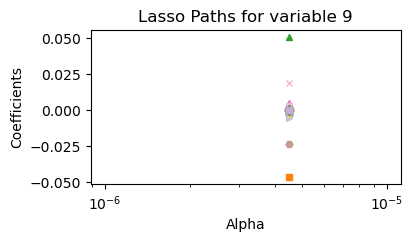

In [ ]:
# coefficient path plotting for each variable

cmap = plt.get_cmap('tab20')
markers = ['.','o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'H', '+', 'x', 'd', '|', '_']

for i in range(0,len(coefs[0,])):
  plt.figure(figsize=(4, 2))
  for j in range(0,len(coefs[0,0,:])):
    plt.plot(lasso_params, coefs[:,i,j],color=cmap(j % cmap.N), marker=markers[j % len(markers)],markersize = 5,label=f'feat {j+1}')
  plt.xscale('log')
  plt.xlabel('Alpha')
  plt.ylabel('Coefficients')
  plt.title(f'Lasso Paths for variable {i+1}')
  plt.axis('tight')
  # plt.legend(loc='upper right',bbox_to_anchor=(1.2, 0.6, 0.5, 0.5),ncols=5)
  plt.show()



In [ ]:
def W_out_test(W_out,total_var):
    # apply W_out to the training feature vector to get the training output
    x_predict = x[0:d,warmup_pts-1:warmtrain_pts-1] + W_out @ out_train[:,0:traintime_pts]

    # calculate NRMSE between true Lorenz and training output
    train_nrmse = np.sqrt(np.mean((x[0:d,warmup_pts:warmtrain_pts]-x_predict[:,:])**2)/total_var)
    

    # create a place to store feature vectors for prediction
    out_test = np.zeros(dtot)              # full feature vector
    x_test = np.zeros((dlin,testtime_pts)) # linear part

    # copy over initial linear feature vector
    x_test[:,0] = x[:,warmtrain_pts-1]

    # do prediction
    for j in range(testtime_pts-1):
        # copy linear part into whole feature vector
        out_test[1:dlin+1]=x_test[:,j] # shift by one for constant
        # fill in the non-linear part
        cnt=0
        for row in range(dlin):
            for column in range(row,dlin):
                # shift by one for constant
                out_test[dlin+1+cnt]=x_test[row,j]*x_test[column,j]
                cnt += 1
        # fill in the delay taps of the next state
        x_test[d:dlin,j+1]=x_test[0:(dlin-d),j]
        # do a prediction
        x_test[0:d,j+1] = x_test[0:d,j]+W_out @ out_test[:]

    # calculate NRMSE between true Lorenz and prediction for one Lyapunov time
    test_nrmse = np.sqrt(np.mean((x[0:d,warmtrain_pts-1:warmtrain_pts+lyaptime_pts-1]-x_test[0:d,0:lyaptime_pts])**2)/total_var)
    
    return(train_nrmse,test_nrmse)


train_nrmse_history = np.array([])
test_nrmse_history = np.array([])
for i in range(0,len(coefs[:,0,:])):
    W_out = np.array(coefs[i,:,:])
    train_nrmse,test_nrmse = W_out_test(W_out,total_var)
    train_nrmse_history = np.append(train_nrmse_history,train_nrmse)
    test_nrmse_history = np.append(test_nrmse_history,test_nrmse)


# plot lasso paramater vs nrmse (to select best paramater value) (?)

# plt.title('train nmrse vs paramater val')
# plt.plot(lasso_params,train_nrmse_history,'-o')
# plt.show()
# plt.title('test nmrse vs paramater val')
# plt.plot(lasso_params,test_nrmse_history,'-o')
# plt.show()

In [ ]:

def W_out_test_plot(W_out):
    # apply W_out to the training feature vector to get the training output
    x_predict = x[0:d,warmup_pts-1:warmtrain_pts-1] + W_out @ out_train[:,0:traintime_pts]

    # calculate NRMSE between true Lorenz and training output
    rms = np.sqrt(np.mean((x[0:d,warmup_pts:warmtrain_pts]-x_predict[:,:])**2)/total_var)
    print('training nrmse: '+str(rms))

    # create a place to store feature vectors for prediction
    out_test = np.zeros(dtot)              # full feature vector
    x_test = np.zeros((dlin,testtime_pts)) # linear part
    
    #add ones to top of feat vec (not in OG code) #critical for lorenz 96 b/c chaos part comes from constant
    out_test[0]=1

    # copy over initial linear feature vector
    x_test[:,0] = x[:,warmtrain_pts-1]

    # do prediction
    for j in range(testtime_pts-1):
        # copy linear part into whole feature vector
        out_test[1:dlin+1]=x_test[:,j] # shift by one for constant
        # fill in the non-linear part
        cnt=0
        for row in range(dlin):
            for column in range(row,dlin):
                # shift by one for constant
                out_test[dlin+1+cnt]=x_test[row,j]*x_test[column,j]
                cnt += 1
        # fill in the delay taps of the next state
        x_test[d:dlin,j+1]=x_test[0:(dlin-d),j]
        # do a prediction
        x_test[0:d,j+1] = x_test[0:d,j]+W_out @ out_test[:]

    # calculate NRMSE between true Lorenz and prediction for one Lyapunov time
    test_nrmse = np.sqrt(np.mean((x[0:d,warmtrain_pts-1:warmtrain_pts+lyaptime_pts-1]-x_test[0:d,0:lyaptime_pts])**2)/total_var)
    print('test nrmse: '+str(test_nrmse))


    ##
    ## Plot
    ##

    # for i in range(0,d):
    #     plt.figure(figsize=(8, 2))
    #     plt.plot(t_eval[:-2],x[i,:-1],'b--',label = 'solution')
    #     plt.plot(t_eval[warmup_pts:warmtrain_pts],x_predict[i],'g-',label='training fit')
    #     plt.plot(t_eval[warmtrain_pts:-1]-dt,x_test[i],'r-',label='prediction'  )
    #     plt.xlabel('time')
    #     plt.ylabel(f'variable {i+1}')
    #     plt.legend(loc='upper right',bbox_to_anchor=(1.2, 0.6, 0.5, 0.5))
    #     plt.xlim(14.5,25.1)
    #     plt.show()

    return x_predict ,x_test

print(total_var,'data variance')
print('-----------------')
print('implicit ridge')
X_predict_ridge,X_test_ridge = W_out_test_plot(W_out_ridge)
print('-----------------')
print('lasso')
coef_idx = 0 # choose wich lasso coefficient to use from 'lasso_params' array
print('lasso tolerance value:',lasso_tol)
W_out_lasso = np.array(coefs[coef_idx,:,:])
X_predict_lasso, X_test_lasso = W_out_test_plot(W_out_lasso)

55.41805798549782 data variance
-----------------
implicit ridge
training nrmse: 1.5199231099772888e-05
test nrmse: 0.0028579900079685463
-----------------
lasso
lasso tolerance value: 1e-06
training nrmse: 6.0030716578877934e-05
test nrmse: 0.012698804489426499


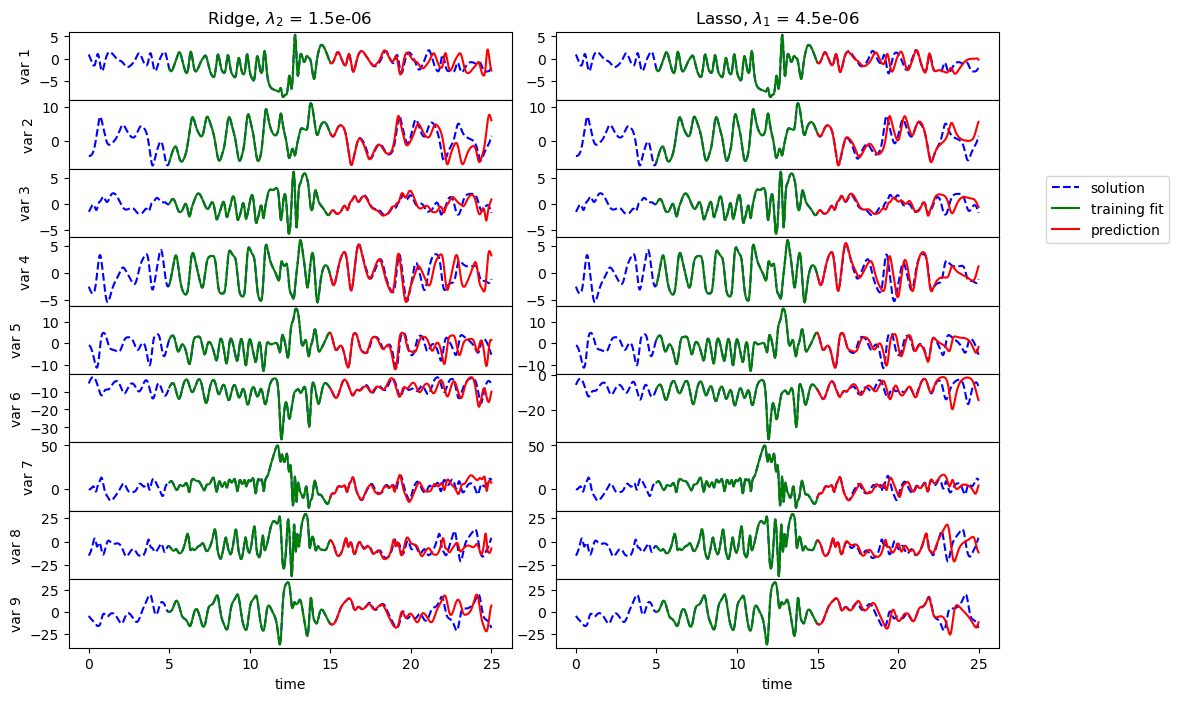

In [ ]:
# plot ridge vs lasso solution
fig, axes = plt.subplots(nrows = d, ncols = 2, figsize=(12, 8),sharex = True)
fig.subplots_adjust(hspace=0,wspace=.1)
axes[0, 0].set_title(f'Ridge, $\\lambda_2$ = {ridge_param}')
axes[0, 1].set_title(f'Lasso, $\\lambda_1$ = {lasso_params[coef_idx]}')


for i in range(0,d):
    axes[i,0].plot(t_eval[:-2],x[i,:-1],'b--',label = 'solution')
    axes[i,0].plot(t_eval[warmup_pts:warmtrain_pts],X_predict_ridge[i],'g-',label='training fit')
    axes[i,0].plot(t_eval[warmtrain_pts:-1]-dt,X_test_ridge[i],'r-',label='prediction'  )
    axes[i,0].set_xlabel('time')
    axes[i,0].set_ylabel(f'var {i+1}')

    axes[i,1].plot(t_eval[:-2],x[i,:-1],'b--',label = 'solution')
    axes[i,1].plot(t_eval[warmup_pts:warmtrain_pts],X_predict_lasso[i],'g-',label='training fit')
    axes[i,1].plot(t_eval[warmtrain_pts:-1]-dt,X_test_lasso[i,0:],'r-',label='prediction'  )
    axes[i,1].set_xlabel('time')

    # axes[0,0].set_xlim(14,25)
    axes[0,1].legend(loc='upper right',bbox_to_anchor=(1.4, -1., 0., 0.))

plt.show()